In [96]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

x = symbols('x')

class func:
    def __init__(self, f, name):
        self.f = f
        self.name = name

    def __call__(self, *args, **kwds):
        return self.f(*args, **kwds)
    
    def __repr__(self):
        return self.name

f = func( lambda x : x**2,       'f' )
g = func( lambda x : 2*x - x**2, 'g' )

phi_ = 2/(1 + sqrt(5))

simplify( [k for k, v in roots( g(f(x)) - x).items() if 0 < k < 1][0] - phi_ )

0

In [98]:
def fixed_point(fun):
    return [r.n(15) for r in real_roots(fun - x) if 0 < r < 1][0]

def cyclic_permutations(seq):
    return [ seq[i:] + seq[:i] for i in range(len(seq), 0, -1) ]

def apply(seq, x):
    #seq = seq.copy()
    while seq:
        x = seq.pop()(x)
    return x

def cycle(seq):
    return [ fixed_point(apply(s,x)) for s in cyclic_permutations(seq) ]

def cycle_fast(seq, cache={}):

    Seq = tuple(seq)
    cyc = cache.get( Seq, None )

    if cyc:
        return cyc
    else:

        x0 = fixed_point(apply(seq.copy(),x))

        cyc = [x0]
        while seq:
            cyc.append( seq.pop()(cyc[-1]) )
        
        for s in cyclic_permutations(Seq):
            cache[s] = cyc[:-1]

        return cyc[:-1]


def diff(points):
    return [1 + abs( 2 * pt - 1 ) for pt in points]

def total_diff(points):
    return simplify( sum(diff(points)) - 2 * phi_ * len(points) ).n(15)

def geomean(points):
    return prod(points) ** (1/len(points))

( cycle_fast([f,g,g,f]), cycle([f,g,g,f]) )

([0.524888598656405, 0.275508040999484, 0.475111401343595, 0.724491959000516],
 [0.524888598656405, 0.275508040999484, 0.475111401343595, 0.724491959000516])

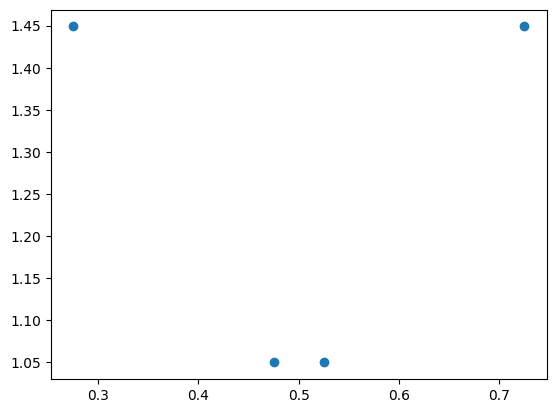

In [99]:
cyc = cycle([f,g,g,f])
plt.scatter(cyc, diff(cyc))

In [100]:
geomean(diff(cycle_fast([f,g,g,f])))

1.23333299493302

In [101]:
def valid_seqs_of_length(n):
    seqs = []

    for i in range(2**n):
        s = []
        for j in range(n):
            if (i >> j) & 1:
                s.append(f)
            else:
                s.append(g)

        if f in s and g in s:
            seqs.append(s)

    return seqs

valid_seqs_of_length(3)

[[f, g, g], [g, f, g], [f, f, g], [g, g, f], [f, g, f], [g, f, f]]

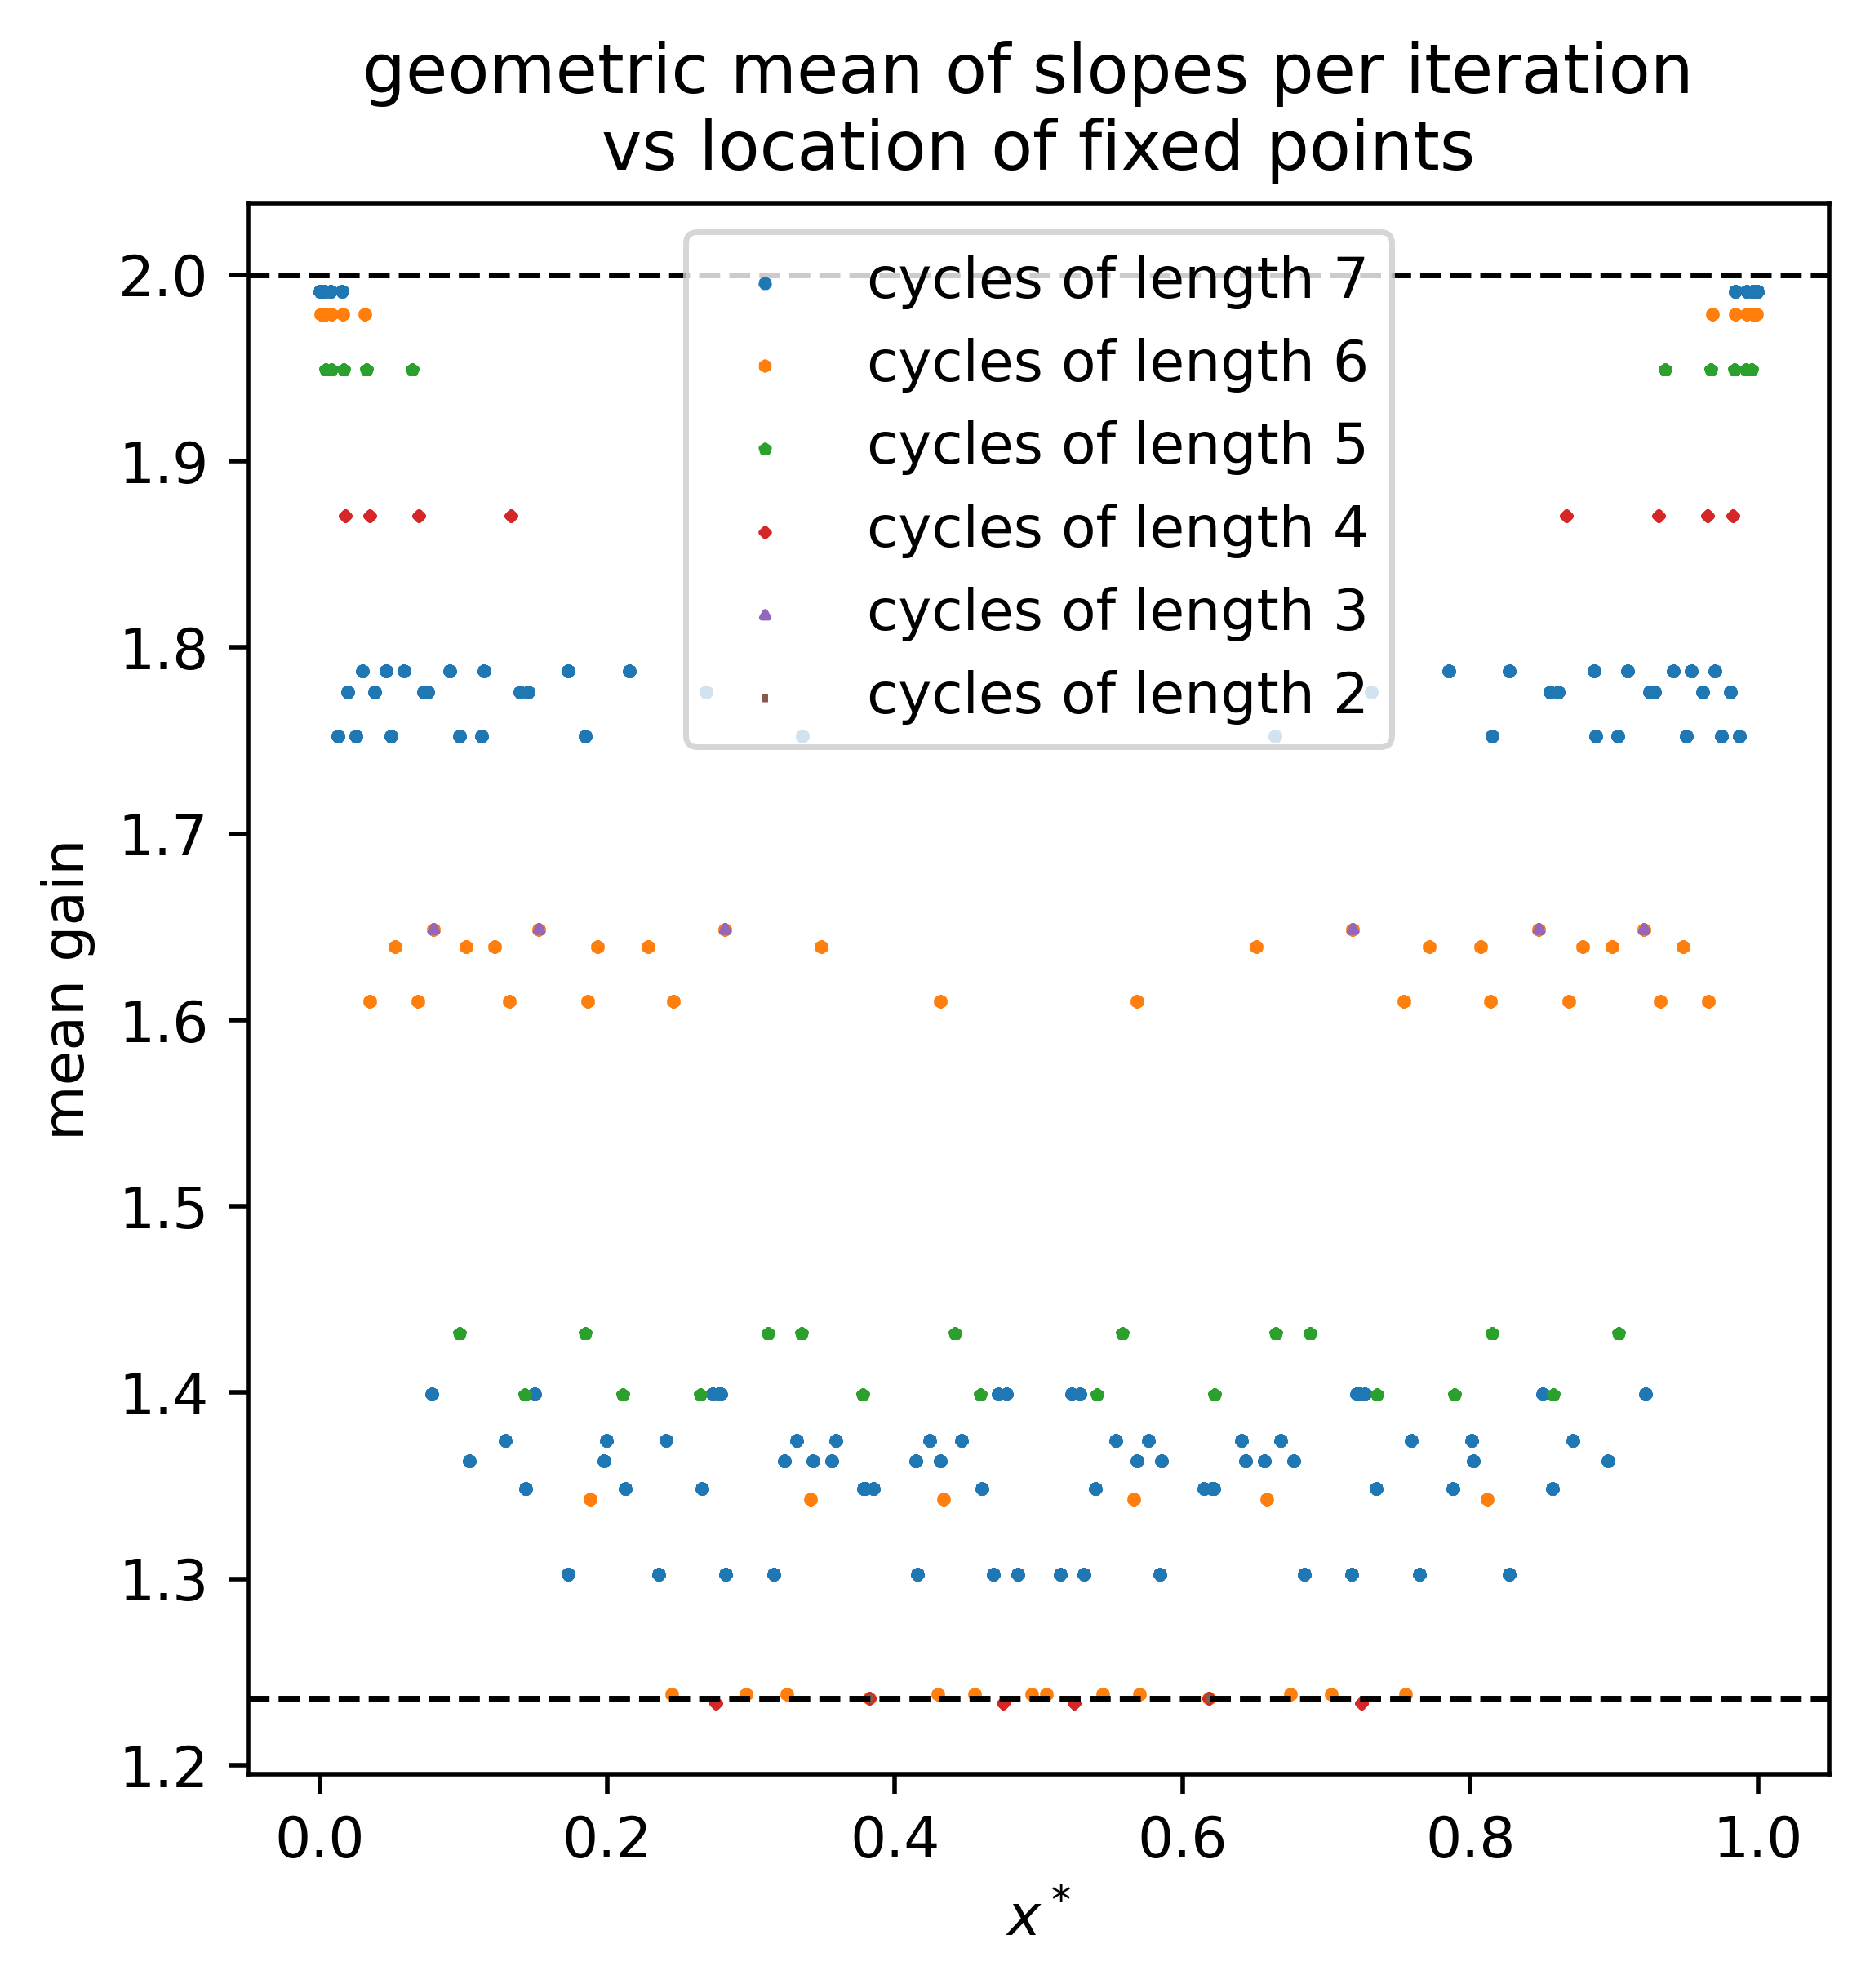

In [215]:
def seqs_and_cycles_of_length(n):
    seqs = valid_seqs_of_length(n)
    return seqs, [cycle_fast(seq) for seq in seqs]

def cycles_and_gains(n):

    seqs, cycs = seqs_and_cycles_of_length(n)

    data = np.array( [[c, [geomean(diff(c))] * len(c)] for c in cycs], dtype=np.float64 )

    duplicates = [[s] * n for s in seqs]

    return [seq for lst in duplicates for seq in lst], data[:,0].flatten(), data[:,1].flatten()

plt.figure(figsize=(5,5), dpi=500)

plt.axhline(2*phi_, 0,1, lw = 1, c='k', ls='--')
plt.axhline(2, 0,1, lw = 1, c='k', ls='--')


for n in range(7,1,-1):
    _, cycles, gains = cycles_and_gains(n)

    plt.scatter(cycles, gains, s=2, marker=(n,0,0), label=f"cycles of length {n}")

plt.xlabel('$x^*$')
plt.ylabel('mean gain')
plt.title("geometric mean of slopes per iteration \nvs location of fixed points")
plt.legend()

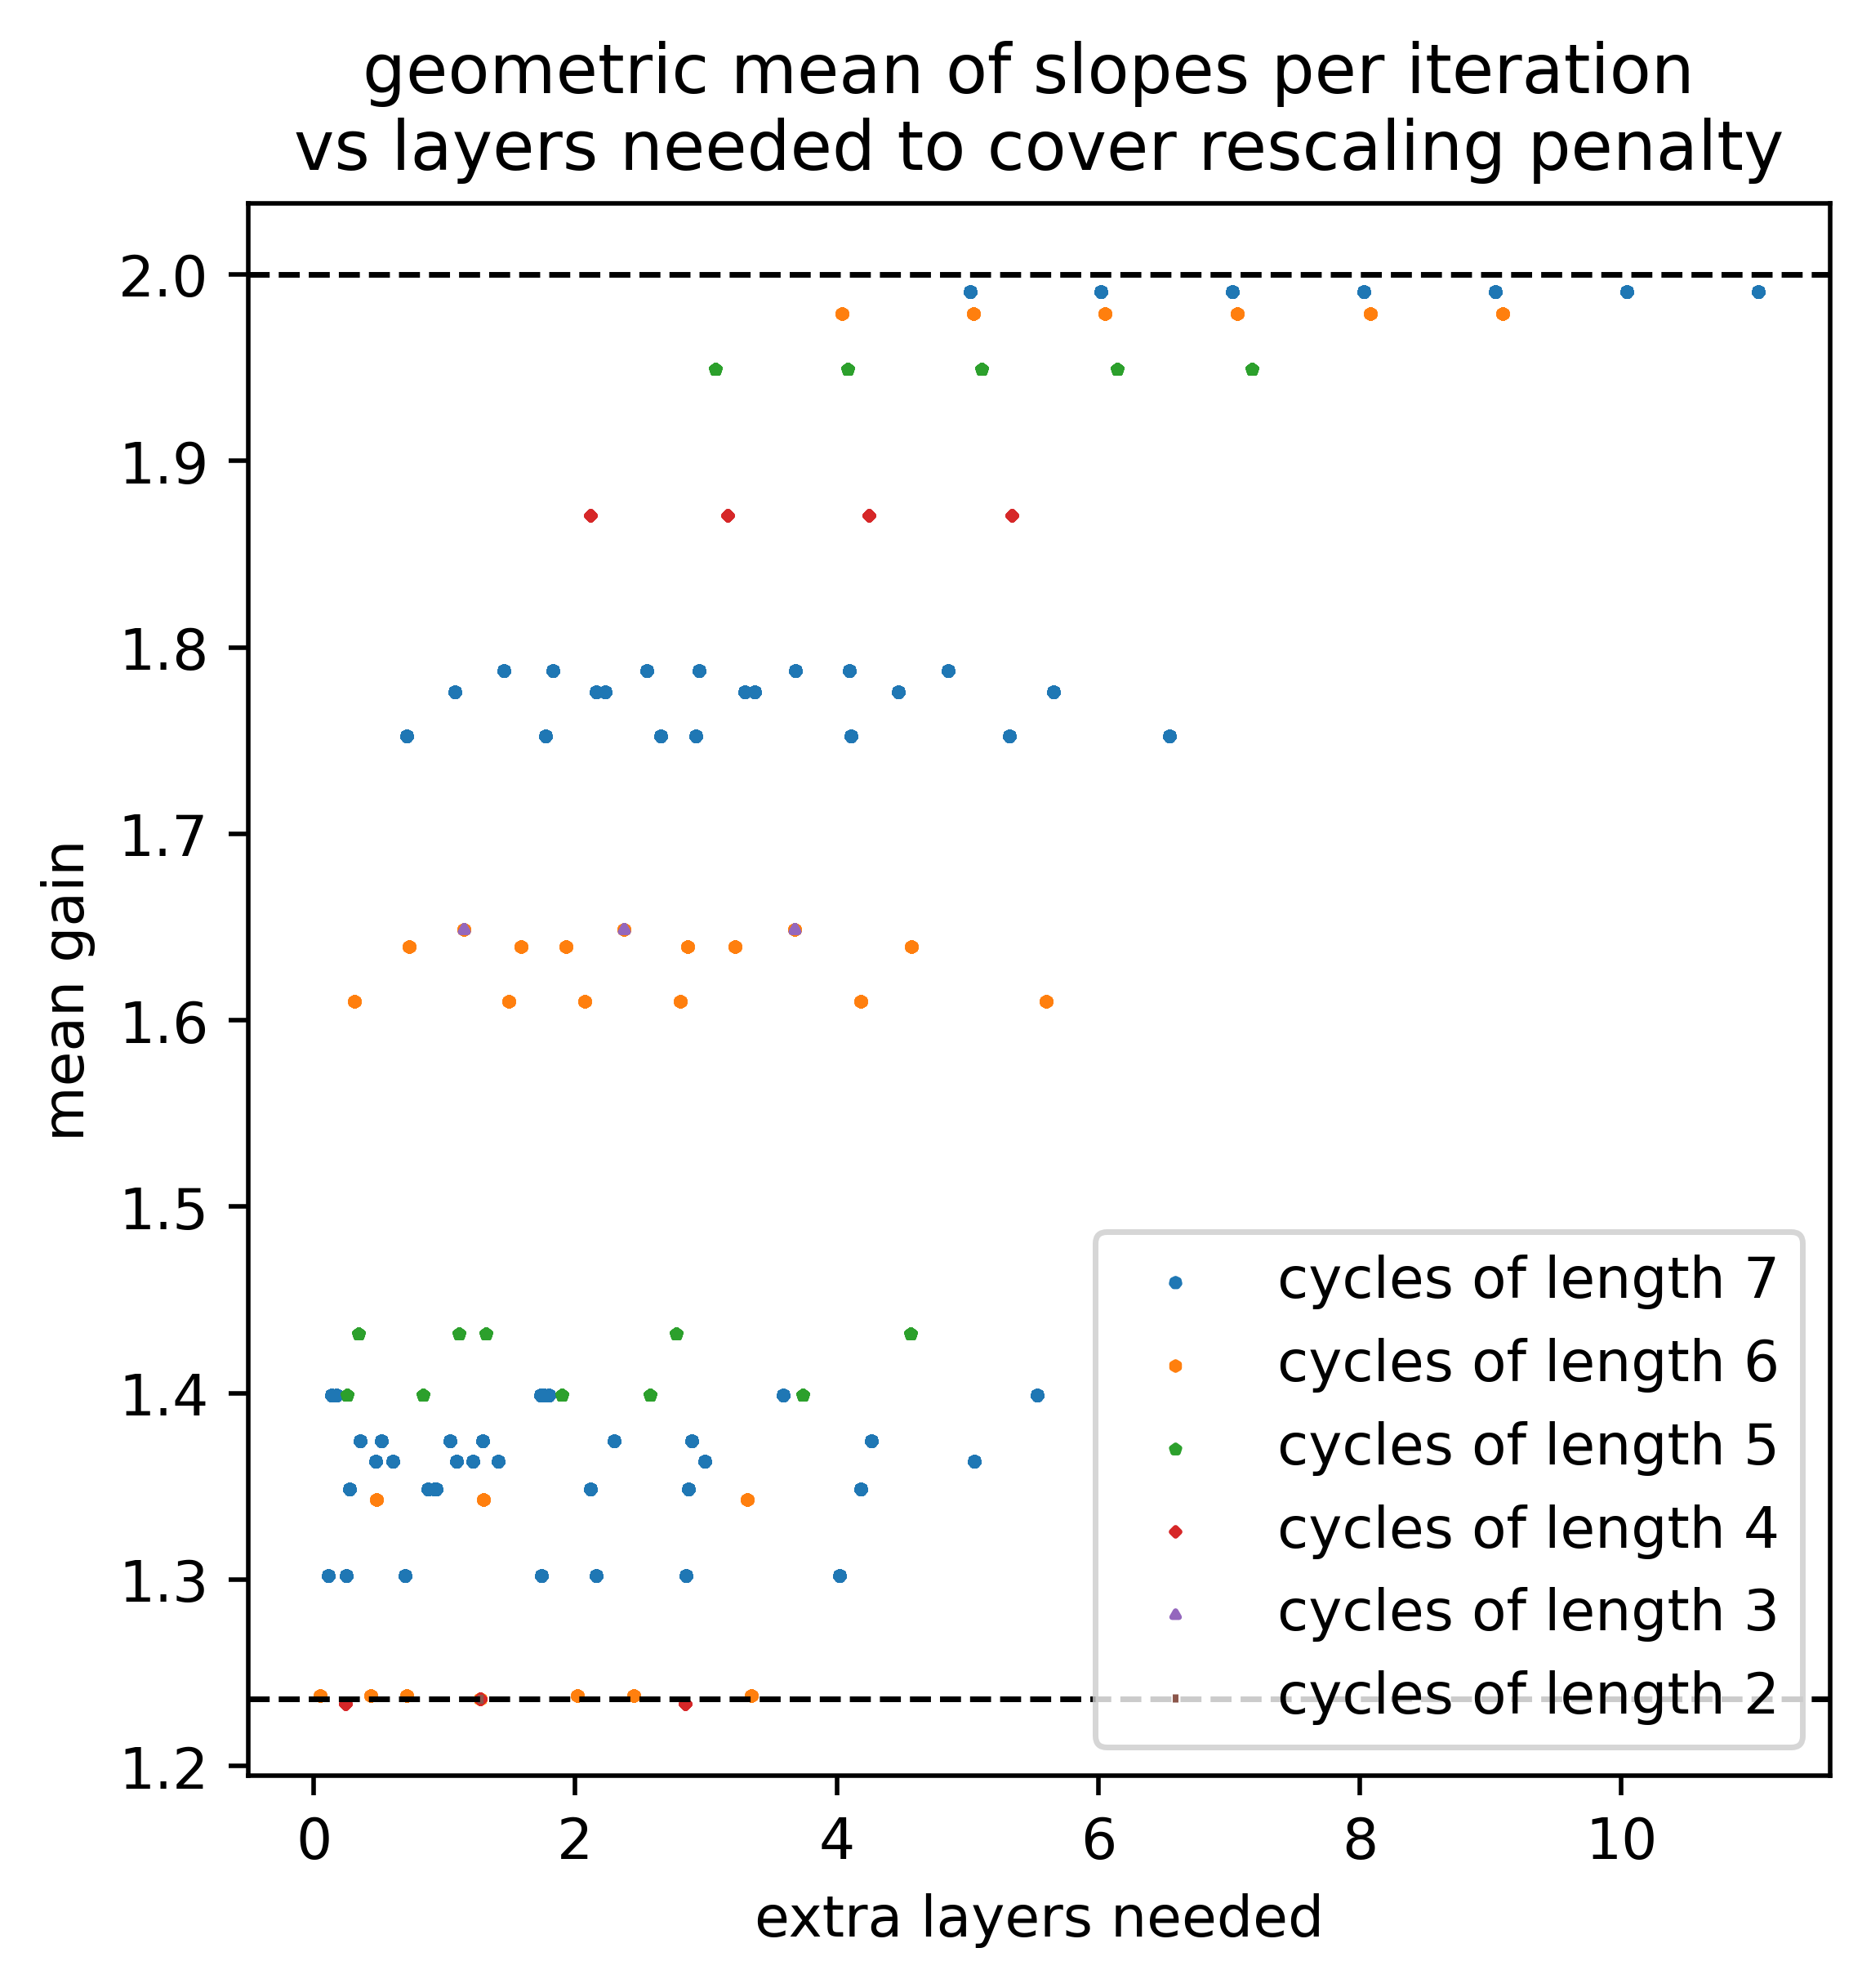

In [216]:
plt.figure(figsize=(5,5), dpi=500)

plt.axhline(2*phi_, 0,1, lw = 1, c='k', ls='--')
plt.axhline(2, 0,1, lw = 1, c='k', ls='--')

S, X, Y = [], [], []

for n in range(7,1,-1):
    seqs, cycles, gains = cycles_and_gains(n)

    scale_factor = 2 * np.where( cycles < (1 - cycles), cycles, 1 - cycles )

    plt.scatter( -np.log(scale_factor)/np.log(gains) , gains, s=2, marker=(n,0,0), label=f"cycles of length {n}")

    S.extend(seqs)
    X.extend(-np.log(scale_factor)/np.log(gains) )
    Y.extend( gains )

slopes = np.linspace(1,1.99,100)

plt.xlabel('extra layers needed')
plt.ylabel('mean gain')
plt.title("geometric mean of slopes per iteration \nvs layers needed to cover rescaling penalty")
plt.legend()

In [217]:
idx = np.argmax(Y)

Y[idx], S[idx]

(1.9910209691625365, [f, f, f, f, f, f, g])

In [ ]:
def is_dominated(row, candidateRow, sense):
    """
    Checks if 'candidateRow' is dominated by 'row' given the optimization sense.
    Sense should be a list of "min" or "max" for each objective.
    """
    # Check if 'row' is better or equal in all objectives
    better_or_equal = [
        row[i] <= candidateRow[i] if sense[i] == "min" else row[i] >= candidateRow[i]
        for i in range(len(row))
    ]
    # Check if 'row' is strictly better in at least one objective
    strictly_better = [
        row[i] < candidateRow[i] if sense[i] == "min" else row[i] > candidateRow[i]
        for i in range(len(row))
    ]
    return all(better_or_equal) and any(strictly_better)


def find_pareto_front(points, sense):
    """
    Finds the Pareto front from a list of points.
    """
    pareto_front = []
    for i, p1 in enumerate(points):
        is_on_front = True
        for j, p2 in enumerate(points):
            if i != j and is_dominated(p2, p1, sense):
                is_on_front = False
                break
        if is_on_front:
            pareto_front.append(p1)
    return np.array(pareto_front)

# Example usage with the same data as above, minimizing both objectives
objective_values = np.array([
    [10, 50], [20, 40], [30, 30], [40, 20], [50, 10], [15, 45], [45, 15]
])
sense = ["min", "min"]
pareto_front_manual = find_pareto_front(objective_values, sense)

print("Pareto Front points (manual):")
print(pareto_front_manual)